# Phase 3 — Multi-gene (3+) Cluster Discovery

**Purpose**: Phase 2 only found gene *pairs*. This notebook groups genes
into clusters of 3 or more, using graph community detection on Phase 2's
significant co-occurring pairs -- genes are nodes, "occurs together more
than chance" pairs are edges, and densely-interconnected groups of genes
become clusters.

**Inputs**: `data/processed/comutation_pairs.parquet` (from Phase 2)

**Output**: `data/processed/gene_clusters_long.parquet` (one row per gene
per cluster) and `data/processed/gene_clusters_summary.parquet` (one row
per cluster, with size/stability/quality metrics).

Self-contained, like Phases 1-2. See `PLAN.md` Phase 3 for methodology.

## Phase 3 data flow, at a glance

```text
comutation_pairs.parquet (50,992 rows, from Phase 2)
              |
              |  keep only CO-OCCURRING pairs (odds_ratio > 1) that are
              |  significant (q_value < 0.05) -- mutually exclusive pairs
              |  are the opposite of a cluster (either/or, not together),
              |  so they're excluded here on purpose
              v
     significant_co_occurring (per cancer type)


for EACH cancer type with enough edges:

  significant_co_occurring pairs for this cancer type
              |
              |  build a graph: genes = nodes, pairs = edges,
              |  edge weight = log2(odds ratio) (stronger co-occurrence
              |  = stronger pull toward the same cluster)
              v
     gene graph (this cancer type)
              |
              |  Louvain community detection: automatically groups nodes
              |  into clusters that are far more interconnected within
              |  the group than across groups
              v
     raw clusters (all sizes)
              |
              |  keep only clusters with >= 3 genes -- a 2-gene cluster
              |  is just a pair, already covered by Phase 2
              v
     clusters of size >= 3
              |
              |  re-run Louvain 20x with different random seeds, check
              |  how often the same gene set stays together -- a proxy
              |  for how trustworthy/stable each cluster is
              v
     stability score per cluster


all clusters, across all cancer types
              |
              v
     gene_clusters_long.parquet + gene_clusters_summary.parquet
     Purpose: the actual multi-gene clusters the FYP's Aim 1 asks for
```


In [ ]:
from itertools import combinations
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms.community import louvain_communities, modularity
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 50)

DATA_DIR = Path.cwd().parent / "data"
PROCESSED_DIR = DATA_DIR / "processed"

Q_VALUE_CUTOFF = 0.05
MIN_CLUSTER_SIZE = 3
N_STABILITY_RUNS = 20

## 1. Load Phase 2 output, keep significant co-occurring pairs only

In [ ]:
pairs = pd.read_parquet(PROCESSED_DIR / "comutation_pairs.parquet")

co_occurring = pairs[(pairs["odds_ratio"] > 1) & (pairs["q_value"] < Q_VALUE_CUTOFF)].copy()
print(f"{len(co_occurring):,} of {len(pairs):,} pairs are significant AND co-occurring (the rest are exclusive or not significant)")

cancer_types_with_edges = co_occurring["Cancer_Type"].value_counts()
cancer_types_with_edges.head(10)

30,556 of 50,992 pairs are significant AND co-occurring (the rest are exclusive or not significant)


Cancer_Type
Endometrial Cancer            7500
Skin Cancer, Non-Melanoma     5885
Melanoma                      3860
Bladder Cancer                2700
Small Bowel Cancer            2123
Colorectal Cancer             1827
Cancer of Unknown Primary     1550
Esophagogastric Cancer         907
Non-Small Cell Lung Cancer     792
Breast Cancer                  444
Name: count, dtype: int64

## 2. Build a graph per cancer type, find clusters with Louvain

Edge weight = `log2_odds_ratio` (already computed in Phase 2 with a
Haldane-Anscombe correction so it's always finite). Louvain maximizes
"modularity" -- roughly, how much more connected genes are within their
assigned group than you'd expect by chance -- to find the grouping.

In [ ]:
def build_graph(cancer_type: str) -> nx.Graph:
    sub = co_occurring[co_occurring["Cancer_Type"] == cancer_type]
    G = nx.Graph()
    for _, row in sub.iterrows():
        G.add_edge(row["Gene_A"], row["Gene_B"], weight=row["log2_odds_ratio"])
    return G


def find_clusters(G: nx.Graph, seed: int = 42):
    return louvain_communities(G, weight="weight", seed=seed)

## 3. Stability check (proxy for bootstrap resampling)

Louvain has some randomness in how it breaks ties. To gauge how trustworthy
a cluster is, re-run it 20 times with different random seeds and measure,
for each base cluster, the average overlap (Jaccard similarity) with its
best-matching cluster in each re-run. A score near 1.0 means the same genes
consistently end up together regardless of randomness; a low score means
the grouping is fragile.

(Note: this is a lighter proxy for full bootstrap resampling -- true
bootstrap would resample patients and rebuild the statistics from scratch,
which is more computationally expensive; worth doing as a follow-up if
these clusters get used for anything downstream.)

In [ ]:
def jaccard(a: set, b: set) -> float:
    return len(a & b) / len(a | b) if (a or b) else 0.0


def stability_scores(G: nx.Graph, base_clusters: list[set], n_runs: int = N_STABILITY_RUNS) -> list[float]:
    rerun_clusters = [find_clusters(G, seed=s) for s in range(1, n_runs + 1)]
    scores = []
    for base in base_clusters:
        best_overlaps = [max(jaccard(base, alt) for alt in run) for run in rerun_clusters]
        scores.append(float(np.mean(best_overlaps)))
    return scores

## 4. Run across all cancer types

In [ ]:
cluster_rows = []
summary_rows = []

for cancer_type in tqdm(cancer_types_with_edges.index):
    G = build_graph(cancer_type)
    if G.number_of_nodes() < MIN_CLUSTER_SIZE:
        continue

    base_clusters = find_clusters(G)
    sized_clusters = [c for c in base_clusters if len(c) >= MIN_CLUSTER_SIZE]
    if not sized_clusters:
        continue

    graph_modularity = modularity(G, base_clusters, weight="weight")
    stabilities = stability_scores(G, sized_clusters)

    for cluster_id, (genes, stability) in enumerate(zip(sized_clusters, stabilities)):
        genes = sorted(genes)
        sub_edges = co_occurring[
            co_occurring["Cancer_Type"].eq(cancer_type)
            & co_occurring["Gene_A"].isin(genes)
            & co_occurring["Gene_B"].isin(genes)
        ]
        mean_log2_or = float(sub_edges["log2_odds_ratio"].mean())

        for gene in genes:
            cluster_rows.append({
                "Cancer_Type": cancer_type, "Cluster_ID": cluster_id, "Hugo_Symbol": gene,
            })
        summary_rows.append({
            "Cancer_Type": cancer_type, "Cluster_ID": cluster_id,
            "Size": len(genes), "Genes": ", ".join(genes),
            "Stability_Score": stability, "Mean_log2_OR": mean_log2_or,
            "Graph_Modularity": graph_modularity,
        })

gene_clusters_long = pd.DataFrame(cluster_rows)
gene_clusters_summary = pd.DataFrame(summary_rows)
print(gene_clusters_long.shape, gene_clusters_summary.shape)
print(f"{gene_clusters_summary['Cancer_Type'].nunique()} cancer types produced at least one cluster")

  0%|          | 0/65 [00:00<?, ?it/s]

(1568, 3) (161, 7)
61 cancer types produced at least one cluster


## 5. Sanity check: does the 11q13 amplicon show up as its own cluster in Breast Cancer?

Phase 2 found `CCND1`/`FGF3`/`FGF4`/`FGF19` strongly co-occurring
(they're physical neighbors on chromosome 11q13) and separately found
them co-occurring with `FGFR1`/`WHSC1L1` (8p12) specifically in Breast
Cancer. If clustering is working, we'd expect to see these genes grouped
together in at least one Breast Cancer cluster.

In [ ]:
breast_clusters = gene_clusters_long[gene_clusters_long["Cancer_Type"] == "Breast Cancer"]
target_genes = {"CCND1", "FGF3", "FGF4", "FGF19", "FGFR1", "WHSC1L1"}

for cluster_id, genes in breast_clusters.groupby("Cluster_ID")["Hugo_Symbol"].apply(set).items():
    overlap = genes & target_genes
    if overlap:
        print(f"Cluster {cluster_id} ({len(genes)} genes) overlaps target set: {sorted(overlap)}")
        print(f"  full cluster: {sorted(genes)}")

Cluster 1 (5 genes) overlaps target set: ['CCND1', 'FGF19', 'FGF3', 'FGF4']
  full cluster: ['CCND1', 'FGF19', 'FGF3', 'FGF4', 'PAK1']
Cluster 3 (6 genes) overlaps target set: ['FGFR1', 'WHSC1L1']
  full cluster: ['FGFR1', 'MYC', 'NBN', 'RAD21', 'RECQL4', 'WHSC1L1']


## 6. Overview: largest and most stable clusters

In [ ]:
print("Largest clusters:")
print(gene_clusters_summary.sort_values("Size", ascending=False)
      [["Cancer_Type", "Cluster_ID", "Size", "Stability_Score", "Genes"]].head(10).to_string())

print("\nMost stable clusters (Stability_Score near 1.0 = robust to re-running):")
print(gene_clusters_summary.sort_values("Stability_Score", ascending=False)
      [["Cancer_Type", "Cluster_ID", "Size", "Stability_Score", "Genes"]].head(10).to_string())

print("\nStability score distribution:")
print(gene_clusters_summary["Stability_Score"].describe())

Largest clusters:
                  Cancer_Type  Cluster_ID  Size  Stability_Score                                                                                                                                                                                                                                                                                                                                                                                   Genes
7                    Melanoma           0    56         0.748467  AR, ARID1A, ARID1B, ARID2, ATR, ATRX, AXL, BCOR, BRCA2, CARD11, CBL, CIC, CREBBP, DICER1, EP300, EPHA3, EPHA7, EPHB1, FAT1, FGFR4, FLT1, FLT4, GLI2, GRIN2A, HGF, IKZF1, KMT2A, KMT2B, KMT2C, KMT2D, MGA, MTOR, NF1, NOTCH3, NOTCH4, NSD1, NTRK1, NTRK3, PAK7, PBRM1, PDGFRB, PIK3C2G, PREX2, PRKDC, PTPRD, PTPRT, RUNX1T1, SETD2, SMARCA4, SPEN, SPTA1, TET2, TP53, TP63, TSC2, ZFHX3
2          Endometrial Cancer           2    56         0.988978                  AKT1, ALK, APC, AR

## 7. Visualize cluster quality

Two checks: (1) the overall distribution of cluster size vs. stability
across all 161 clusters, to see the large/low-stability pattern flagged
in the Discussion section at a glance; (2) actual network drawings for a
few representative cancer types, so the clusters can be inspected
visually rather than just read as gene-name lists.

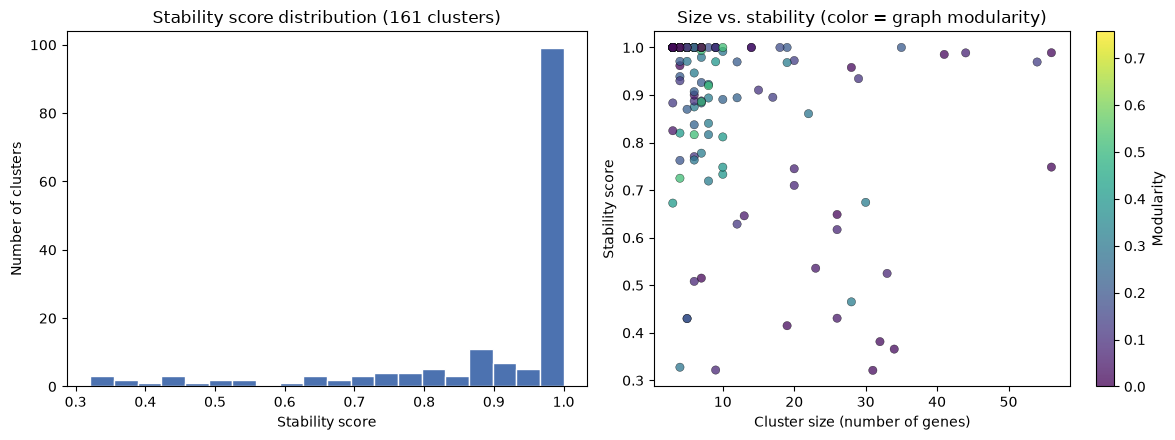

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(gene_clusters_summary["Stability_Score"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Stability score")
axes[0].set_ylabel("Number of clusters")
axes[0].set_title("Stability score distribution (161 clusters)")

scatter = axes[1].scatter(
    gene_clusters_summary["Size"], gene_clusters_summary["Stability_Score"],
    c=gene_clusters_summary["Graph_Modularity"], cmap="viridis", alpha=0.75, edgecolor="k", linewidth=0.3,
)
axes[1].set_xlabel("Cluster size (number of genes)")
axes[1].set_ylabel("Stability score")
axes[1].set_title("Size vs. stability (color = graph modularity)")
fig.colorbar(scatter, ax=axes[1], label="Modularity")

plt.tight_layout()
plt.show()

### Network drawings for 3 representative cancer types

- **Pancreatic Cancer** — small, tight, high-stability clusters (the
  {KRAS, TP53, SMAD4, KDM6A} and {CDKN2A, CDKN2B, MTAP} clusters from the
  sanity checks above).
- **Breast Cancer** — to see the 11q13 vs. 8p12 clusters as visually
  distinct-but-adjacent groups.
- **Melanoma** — the large, lower-stability cluster, to see what a
  TMB-driven "everything correlates" cluster actually looks like next to
  the tight ones above, rather than just reading "56 genes" as a number.

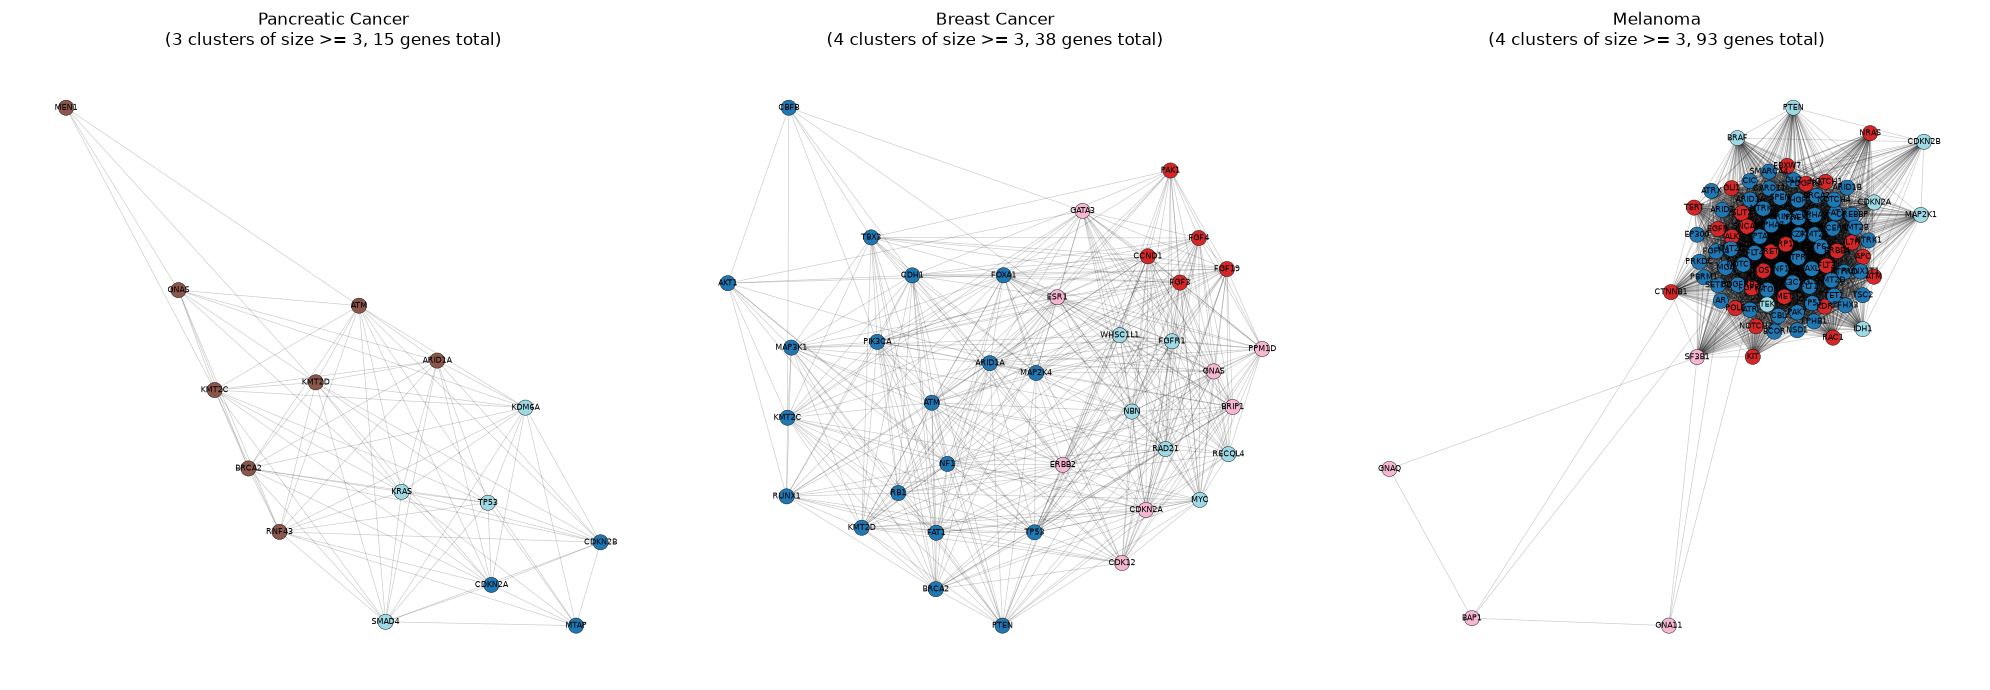

In [ ]:
def plot_cancer_type_clusters(cancer_type: str, ax, seed: int = 42):
    G = build_graph(cancer_type)
    clusters = find_clusters(G, seed=seed)
    clusters = [c for c in clusters if len(c) >= MIN_CLUSTER_SIZE]

    color_map = {}
    palette = plt.colormaps["tab20"].resampled(max(len(clusters), 1))
    for i, cluster in enumerate(clusters):
        for gene in cluster:
            color_map[gene] = palette(i)
    node_colors = [color_map.get(n, "lightgray") for n in G.nodes()]

    pos = nx.spring_layout(G, seed=seed, weight="weight", k=0.6)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=120, edgecolors="black", linewidths=0.3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
    ax.set_title(f"{cancer_type}\n({len(clusters)} clusters of size >= {MIN_CLUSTER_SIZE}, {G.number_of_nodes()} genes total)")
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, ct in zip(axes, ["Pancreatic Cancer", "Breast Cancer", "Melanoma"]):
    plot_cancer_type_clusters(ct, ax)
plt.tight_layout()
plt.show()

## 8. Save output

In [ ]:
gene_clusters_long.to_parquet(PROCESSED_DIR / "gene_clusters_long.parquet", index=False)
gene_clusters_summary.to_parquet(PROCESSED_DIR / "gene_clusters_summary.parquet", index=False)
print(f"saved {len(gene_clusters_long):,} gene-cluster rows and {len(gene_clusters_summary):,} clusters")

saved 1,568 gene-cluster rows and 161 clusters


## Discussion

**Insight:** several clusters matched established, named cancer biology
without being targeted -- the Pancreatic Cancer {KRAS, TP53, SMAD4,
KDM6A} cluster is essentially the textbook 4-driver-gene panel for that
cancer; {CDKN2A, CDKN2B, IKZF1} in B-ALL and {BAP1, LATS2, PBRM1, SETD2}
in Mesothelioma are both well-documented, named genomic patterns. All
three hit a stability score of 1.0 (fully reproducible across 20 reruns
with different random seeds). Separately, the 11q13/8p12 sanity check
showed Louvain correctly kept the two amplicons as distinct-but-linked
clusters rather than merging them -- evidence the method is capturing
real structure, not just lumping everything connected into one blob.

**Result:** 161 clusters (size >= 3) found across 61 of 69 qualifying
cancer types, from 1,568 total gene-cluster membership rows.

**Limitations:**
- The largest clusters (54-56 genes, in Melanoma/Endometrial/Bladder --
  all high mutation-burden cancers) have lower stability (0.32-0.99) and
  likely reflect general co-mutation via overall TMB rather than a tight
  functional module. These should be treated with more caution than the
  small, stability=1.0 clusters when discussing results.
- The stability score is a proxy (Louvain re-run with different random
  seeds) rather than the bootstrap-resampling-over-patients approach
  `PLAN.md` originally specified -- cheaper to compute, but doesn't
  capture sensitivity to which patients happen to be in the dataset.
- `PLAN.md` Phase 3 also proposed comparing this graph-based approach
  against frequent itemset mining (Apriori/FP-growth) and picking
  whichever gives more interpretable clusters -- only the graph approach
  was implemented. Worth doing the comparison if cluster quality becomes
  a concern later.
- Louvain's resolution parameter was left at its default (1.0) --  not
  swept or tuned, so cluster granularity (how "chunky" vs. "fine" the
  groupings are) hasn't been explored as a sensitivity check.

**Open questions:** should very large, low-stability clusters be
excluded from Phase 4's survival analysis entirely, or kept but flagged?
Is a resolution-parameter sweep worth doing before treating cluster
membership as final?


## Next steps (Phase 4)

Merge `gene_clusters_long.parquet` with `clinical_tidy.parquet`'s survival
fields (`DEAD`, `YEAR_DEATH`/`INT_DOD`) to test whether membership in a
cluster is associated with survival -- Kaplan-Meier + log-rank per
cluster vs. the rest of that cancer type. See `PLAN.md` Phase 4. Note
GENIE's survival data is coarse (year-level) and only available for a
subset of centers -- worth checking coverage before running this.